In [ ]:
import random
import numpy as np
from collections import deque
from rdkit import Chem
from rdkit.Chem import QED, Crippen
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from rdkit.Chem import Draw
import seaborn as sns
from matplotlib import animation
from IPython.display import HTML

In [ ]:
# Molecule building blocks
fragments = ['C', 'CC', 'N', 'O', 'Cl', 'C=O', 'c1ccccc1']

In [ ]:
def encode_smiles(smiles, max_len=64):
    vec = [ord(c) for c in smiles[:max_len]]
    return np.array(vec + [0] * (max_len - len(vec)), dtype=np.float32)

In [ ]:
def penalized_logp(mol):
    log_p = Crippen.MolLogP(mol)
    qed_score = QED.qed(mol)
    return log_p + qed_score

### Environment DrugMDP

In [ ]:
class DrugMDP:
    def __init__(self, max_steps=10):
        self.max_steps = max_steps
        self.reset()

    def reset(self):
        self.mol = Chem.MolFromSmiles('C')
        self.steps = 0
        return self.get_state()

    def get_state(self):
        return encode_smiles(Chem.MolToSmiles(self.mol))

    def get_action_space(self):
        return list(range(len(fragments)))

    def apply_fragment(self, mol, frag_smiles):
        try:
            frag = Chem.MolFromSmiles(frag_smiles)
            combo = Chem.CombineMols(mol, frag)
            editable = Chem.EditableMol(combo)
            new_mol = editable.GetMol()
            Chem.SanitizeMol(new_mol)
            return new_mol
        except:
            return None

    def step(self, action):
        frag = fragments[action]
        new_mol = self.apply_fragment(self.mol, frag)
        if new_mol is None:
            return self.get_state(), -1.0, True

        self.mol = new_mol
        self.steps += 1
        reward = penalized_logp(self.mol)
        done = self.steps >= self.max_steps
        return self.get_state(), reward, done


In [ ]:
class DQN(nn.Module):
    def __init__(self, state_size, action_size):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_size, 128)
        self.fc2 = nn.Linear(128, 128)
        self.out = nn.Linear(128, action_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.out(x)

In [ ]:
# Experience Replay Buffer
class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        states, actions, rewards, next_states, dones = zip(*random.sample(self.buffer, batch_size))
        return (np.array(states), actions, rewards, np.array(next_states), dones)

    def __len__(self):
        return len(self.buffer)


In [ ]:
#Epsilon Greedy Policy
def select_action(model, state, epsilon, action_size):
    if random.random() < epsilon:
        return random.randint(0, action_size - 1)
    state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        q_values = model(state_tensor)
    return torch.argmax(q_values).item()

In [ ]:
env = DrugMDP(max_steps=10)
state_size = 64
action_size = len(fragments)
policy_net = DQN(state_size, action_size)
target_net = DQN(state_size, action_size)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()
optimizer = optim.Adam(policy_net.parameters(), lr=1e-3)
replay_buffer = ReplayBuffer()

epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.995
gamma = 0.99
batch_size = 64
num_episodes = 300
target_update_freq = 10

episode_rewards = []
top_molecules = []
animation_smiles = []
animation_episode = 50

In [ ]:
for episode in range(1, num_episodes + 1):
    state = env.reset()
    total_reward = 0

    for _ in range(env.max_steps):
        action = select_action(policy_net, state, epsilon, action_size)
        next_state, reward, done = env.step(action)

        if episode == animation_episode:
            mol = Chem.MolFromSmiles(Chem.MolToSmiles(env.mol))
            animation_smiles.append(mol)

        replay_buffer.push(state, action, reward, next_state, done)
        top_molecules.append((reward, Chem.MolFromSmiles(Chem.MolToSmiles(env.mol))))
        top_molecules = sorted(top_molecules, key=lambda x: x[0], reverse=True)[:5]

        state = next_state
        total_reward += reward
        if done:
            break

        if len(replay_buffer) >= batch_size:
            states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)

            states_tensor = torch.tensor(states, dtype=torch.float32)
            actions_tensor = torch.tensor(actions, dtype=torch.int64).unsqueeze(1)
            rewards_tensor = torch.tensor(rewards, dtype=torch.float32).unsqueeze(1)
            next_states_tensor = torch.tensor(next_states, dtype=torch.float32)
            dones_tensor = torch.tensor(dones, dtype=torch.float32).unsqueeze(1)

            current_q = policy_net(states_tensor).gather(1, actions_tensor)
            max_next_q = target_net(next_states_tensor).max(1)[0].detach().unsqueeze(1)
            expected_q = rewards_tensor + (gamma * max_next_q * (1 - dones_tensor))

            loss = nn.MSELoss()(current_q, expected_q)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    if episode % target_update_freq == 0:
        target_net.load_state_dict(policy_net.state_dict())

    epsilon = max(epsilon * epsilon_decay, epsilon_min)
    episode_rewards.append(total_reward)
    if episode % 10 == 0:
        print(f"Episode {episode}, Total Reward: {total_reward:.2f}, Epsilon: {epsilon:.3f}")


Episode 10, Total Reward: 52.23, Epsilon: 0.951
Episode 20, Total Reward: 28.82, Epsilon: 0.905
Episode 30, Total Reward: 58.76, Epsilon: 0.860
Episode 40, Total Reward: 56.00, Epsilon: 0.818
Episode 50, Total Reward: 42.97, Epsilon: 0.778
Episode 60, Total Reward: 6.58, Epsilon: 0.740
Episode 70, Total Reward: 45.57, Epsilon: 0.704
Episode 80, Total Reward: 36.54, Epsilon: 0.670
Episode 90, Total Reward: 37.21, Epsilon: 0.637
Episode 100, Total Reward: 43.76, Epsilon: 0.606
Episode 110, Total Reward: 42.24, Epsilon: 0.576
Episode 120, Total Reward: 37.07, Epsilon: 0.548
Episode 130, Total Reward: 55.17, Epsilon: 0.521
Episode 140, Total Reward: 50.73, Epsilon: 0.496
Episode 150, Total Reward: 48.36, Epsilon: 0.471
Episode 160, Total Reward: 47.24, Epsilon: 0.448
Episode 170, Total Reward: 52.71, Epsilon: 0.427
Episode 180, Total Reward: 59.67, Epsilon: 0.406
Episode 190, Total Reward: 73.16, Epsilon: 0.386
Episode 200, Total Reward: 34.86, Epsilon: 0.367
Episode 210, Total Reward: 55.

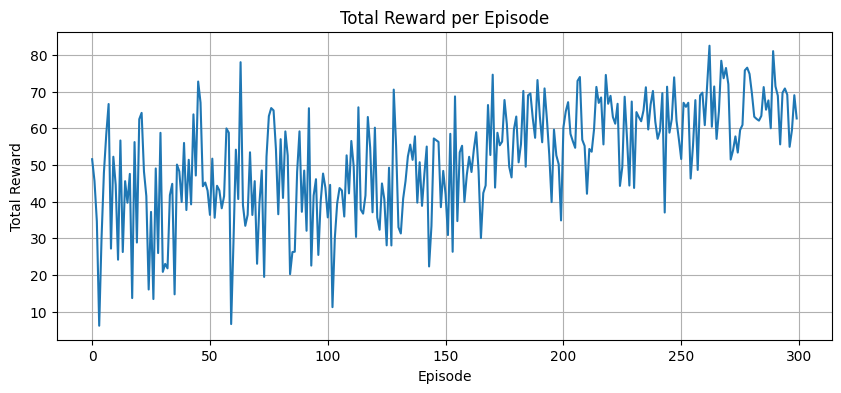

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(episode_rewards)
plt.title("Total Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.show()

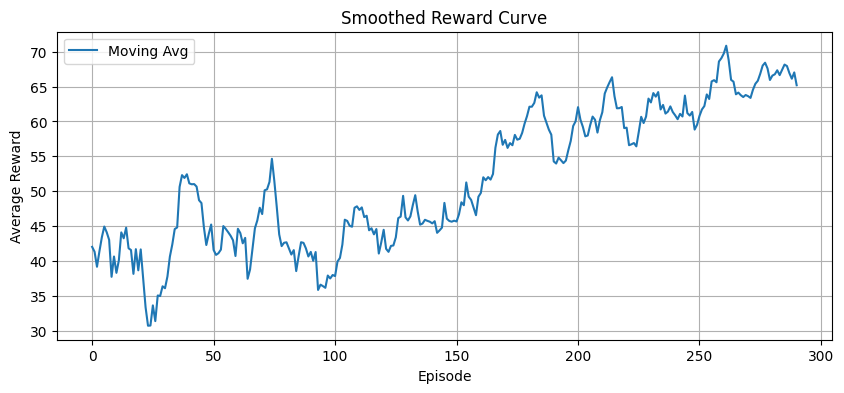

In [ ]:
def moving_avg(data, window=10):
    return np.convolve(data, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10, 4))
plt.plot(moving_avg(episode_rewards), label='Moving Avg')
plt.title("Smoothed Reward Curve")
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.grid(True)
plt.legend()
plt.show()


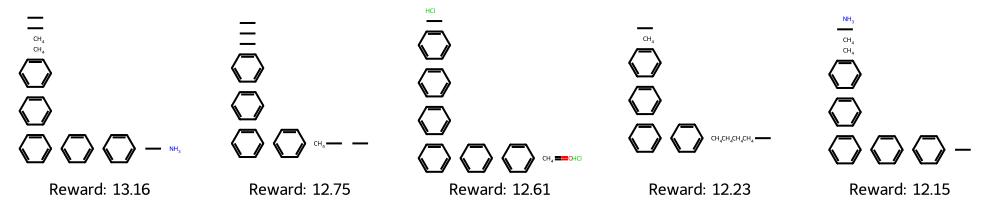

In [ ]:
mols = [mol for _, mol in top_molecules]
legends = [f"Reward: {r:.2f}" for r, _ in top_molecules]
Draw.MolsToGridImage(mols, molsPerRow=5, subImgSize=(200, 200), legends=legends)

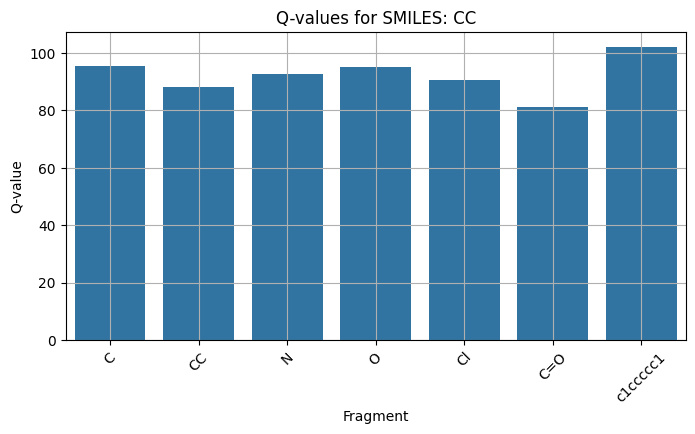

In [ ]:
test_smiles = "CC"
state_vector = encode_smiles(test_smiles)
state_tensor = torch.tensor(state_vector, dtype=torch.float32).unsqueeze(0)
q_vals = policy_net(state_tensor).detach().numpy().flatten()

plt.figure(figsize=(8, 4))
sns.barplot(x=fragments, y=q_vals)
plt.title(f"Q-values for SMILES: {test_smiles}")
plt.ylabel("Q-value")
plt.xlabel("Fragment")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [ ]:
frames = [Draw.MolToImage(mol, size=(200, 200)) for mol in animation_smiles]
fig, ax = plt.subplots()

def update(frame):
    ax.clear()
    ax.imshow(frame)
    ax.axis('off')

ani = animation.FuncAnimation(fig, update, frames=frames, interval=1000)
plt.close()
HTML(ani.to_jshtml())